In [28]:
#z-score calculation and plotiing for bilionaries datsset 
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt

In [32]:
df=pd.read_csv("2022_forbes_billionaires.csv")
df

,Unnamed: 0,rank,name,networth,age,country,source,industry
0,0,1,Elon Musk,$219 B,50,United States,"Tesla, SpaceX",Automotive
1,1,2,Jeff Bezos,$171 B,58,United States,Amazon,Technology
2,2,3,Bernard Arnault & family,$158 B,73,France,LVMH,Fashion & Retail
3,3,4,Bill Gates,$129 B,66,United States,Microsoft,Technology
4,4,5,Warren Buffett,$118 B,91,United States,Berkshire Hathaway,Finance & Investments
...,...,...,...,...,...,...,...,...
2595,2595,2578,Jorge Gallardo Ballart,$1 B,80,Spain,pharmaceuticals,Healthcare
2596,2596,2578,Nari Genomal,$1 B,82,Philippines,apparel,Fashion & Retail
2597,2597,2578,Ramesh Genomal,$1 B,71,Philippines,apparel,Fashion & Retail
2598,2598,2578,Sunder Genomal,$1 B,68,Philippines,garments,Fashion & Retail


In [33]:
df["networth"]=df["networth"].str.replace('$','',regex=False) #remove $
df["networth"]=df["networth"].str.replace(' B','',regex=False)#remove B
df["networth"]=pd.to_numeric(df['networth'],errors='coerce')
df=df.dropna(subset=['networth'])

df['networth_zscore']=zscore(df['networth'])
df['networth_percentile']=df['networth'].rank(pct=True)*100

networth_mean =df['networth'].mean()
networth_std=df['networth'].std()
print(f"Mean of networth:{networth_mean:.2f} B")
print(f"Standard devitaion of networth:{networth_std:.2f} B")
print(df.head())
print(df.tail())

Mean of networth:4.86 B
Standard devitaion of networth:10.66 B
   Unnamed: 0  rank                       name  networth  age        country  \
0           0     1                 Elon Musk      219.0   50  United States   
1           1     2                Jeff Bezos      171.0   58  United States   
2           2     3  Bernard Arnault & family      158.0   73         France   
3           3     4                Bill Gates      129.0   66  United States   
4           4     5            Warren Buffett      118.0   91  United States   

               source                industry  networth_zscore  \
0       Tesla, SpaceX             Automotive         20.092595   
1              Amazon             Technology         15.588775   
2                LVMH       Fashion & Retail         14.368991   
3           Microsoft             Technology         11.647933   
4  Berkshire Hathaway  Finance & Investments         10.615808   

   networth_percentile  
0           100.000000  
1        

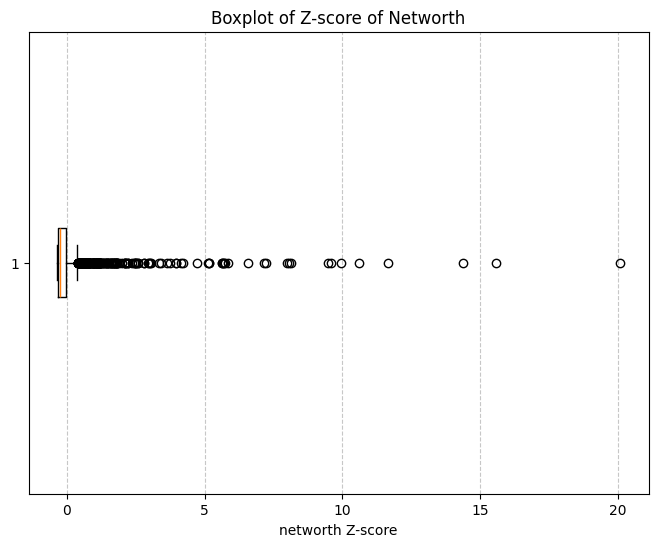

In [37]:
plt.figure(figsize=(8,6))
plt.boxplot(df['networth_zscore'],vert=False)
plt.title("Boxplot of Z-score of Networth")
plt.xlabel("networth Z-score")
plt.grid(axis='x',linestyle='--',alpha=0.7)
plt.show()